In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [21]:
df = pd.DataFrame([
    {"Location":"Najafgarh","NDVI":0.10,"NO2":0.00009,"Temperature":41},
    {"Location":"Bawana","NDVI":0.06,"NO2":0.00010,"Temperature":46},
    {"Location":"Okhla","NDVI":0.37,"NO2":0.00013,"Temperature":43},
    {"Location":"Palam","NDVI":0.02,"NO2":0.00012,"Temperature":38},
    {"Location":"Badarpur","NDVI":0.34,"NO2":0.00013,"Temperature":44},
])

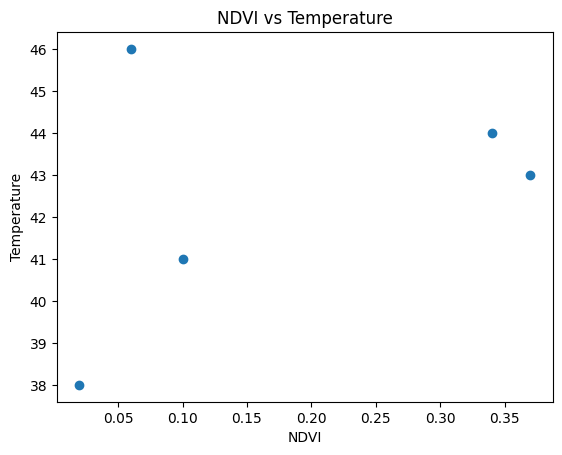

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["NDVI"], df["Temperature"])
plt.xlabel("NDVI")
plt.ylabel("Temperature")
plt.title("NDVI vs Temperature")

plt.savefig("graphs/ndvi_vs_temp.png", dpi=300, bbox_inches="tight")
plt.show()

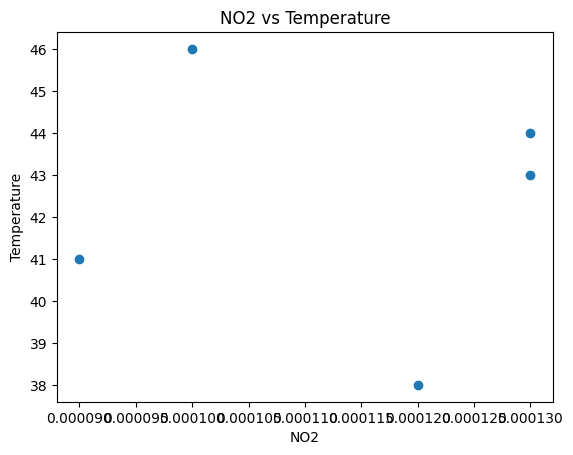

In [23]:
plt.figure()
plt.scatter(df["NO2"], df["Temperature"])
plt.xlabel("NO2")
plt.ylabel("Temperature")
plt.title("NO2 vs Temperature")

plt.savefig("graphs/no2_vs_temp.png", dpi=300, bbox_inches="tight")
plt.show()

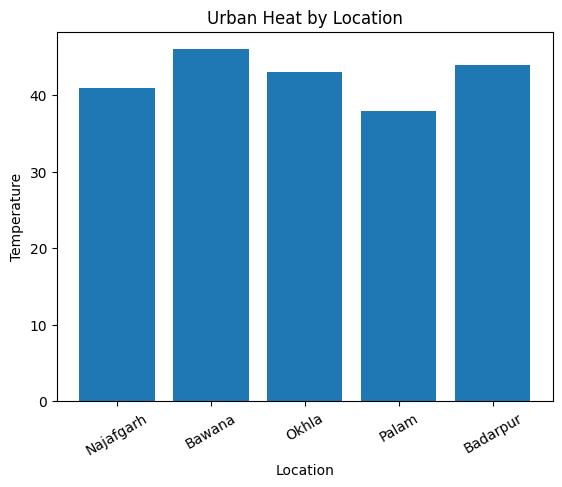

In [24]:
plt.figure()
plt.bar(df["Location"], df["Temperature"])
plt.xlabel("Location")
plt.ylabel("Temperature")
plt.title("Urban Heat by Location")
plt.xticks(rotation=30)

plt.savefig("graphs/temp_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
plt.savefig("graphs/ah_2010_vs_2050.png")

<Figure size 640x480 with 0 Axes>

In [26]:
print(df.head())
print(df.head())

    Location  NDVI      NO2  Temperature
0  Najafgarh  0.10  0.00009           41
1     Bawana  0.06  0.00010           46
2      Okhla  0.37  0.00013           43
3      Palam  0.02  0.00012           38
4   Badarpur  0.34  0.00013           44
    Location  NDVI      NO2  Temperature
0  Najafgarh  0.10  0.00009           41
1     Bawana  0.06  0.00010           46
2      Okhla  0.37  0.00013           43
3      Palam  0.02  0.00012           38
4   Badarpur  0.34  0.00013           44


In [27]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [28]:
def load_tif(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)
    return data

In [29]:
AH_2010_year = load_tif("data/AHE_2010_year.tif")
AH_2050_year = load_tif("data/AHE_2050_year.tif")

df_ah_2010 = pd.DataFrame({"AH": AH_2010_year.flatten()})
df_ah_2050 = pd.DataFrame({"AH": AH_2050_year.flatten()})

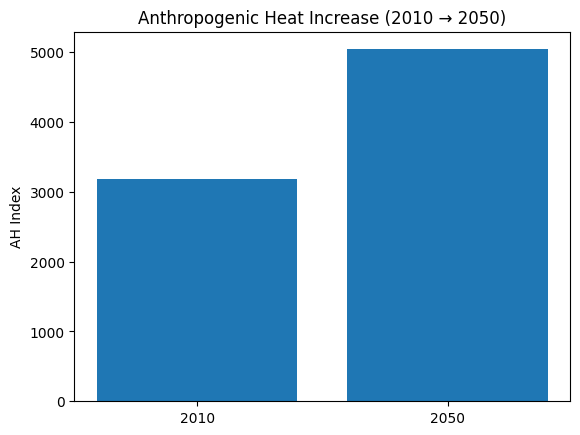

In [30]:
import matplotlib.pyplot as plt

plt.figure()

vals = [
    np.nanmean(df_ah_2010["AH"]),
    np.nanmean(df_ah_2050["AH"])
]

plt.bar(["2010", "2050"], vals)

plt.title("Anthropogenic Heat Increase (2010 → 2050)")
plt.ylabel("AH Index")

plt.savefig("graphs/ah_2010_vs_2050.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
data = {
    "Area": [
        "Najafgarh",
        "Bawana Industrial",
        "Okhla Estate",
        "Palam Airport",
        "Badarpur"
    ],

    # placeholder AH values (you can later replace with model output)
    "AH_Index": [82, 88, 76, 70, 79]
}

df = pd.DataFrame(data)
df

,Area,AH_Index
0,Najafgarh,82
1,Bawana Industrial,88
2,Okhla Estate,76
3,Palam Airport,70
4,Badarpur,79


In [33]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

os.makedirs("graphs", exist_ok=True)

path_2010 = "data/AHE_2010_year.tif"
path_2050 = "data/AHE_2050_year.tif"

In [34]:
def raster_mean(path):
    with rasterio.open(path) as src:
        data = src.read(1)  # first band
        data = data.astype("float32")

        # handle nodata if present
        data[data == src.nodata] = np.nan

        return np.nanmean(data)

In [35]:
ah_2010 = raster_mean(path_2010)
ah_2050 = raster_mean(path_2050)

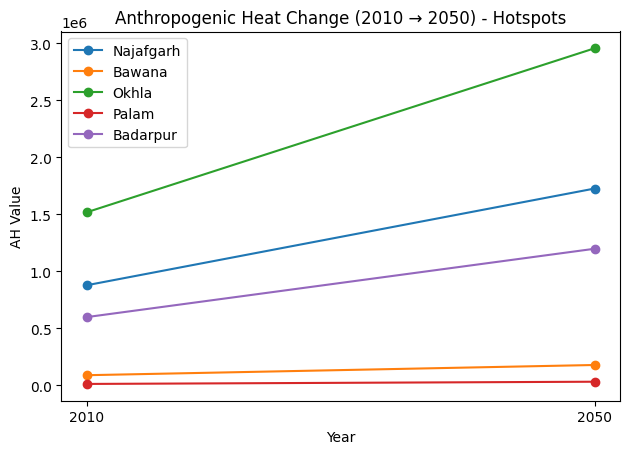

In [42]:
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

HOTSPOTS = pd.DataFrame([
    {"Location":"Najafgarh","Latitude":28.6090,"Longitude":76.9855,"NDVI":0.10,"NO2":0.00009,"Temperature":41},
    {"Location":"Bawana","Latitude":28.7988,"Longitude":77.0329,"NDVI":0.06,"NO2":0.00010,"Temperature":46},
    {"Location":"Okhla","Latitude":28.5284,"Longitude":77.2721,"NDVI":0.37,"NO2":0.00013,"Temperature":43},
    {"Location":"Palam","Latitude":28.5606,"Longitude":77.1040,"NDVI":0.02,"NO2":0.00012,"Temperature":38},
    {"Location":"Badarpur","Latitude":28.5036,"Longitude":77.3045,"NDVI":0.34,"NO2":0.00013,"Temperature":44},
])

# -----------------------------
# Function: get value from raster
# -----------------------------
def get_value(tif_path, lon, lat):
    with rasterio.open(tif_path) as src:
        for val in src.sample([(lon, lat)]):
            return float(val[0])

# -----------------------------
# Extract data (FIXED LOOP)
# -----------------------------
names = []
ah_2010 = []
ah_2050 = []

for _, h in HOTSPOTS.iterrows():   # ✅ FIX HERE
    name = h["Location"]
    lon = h["Longitude"]
    lat = h["Latitude"]

    v2010 = get_value("data/ahe_2010_year.tif", lon, lat)
    v2050 = get_value("data/ahe_2050_year.tif", lon, lat)

    names.append(name)
    ah_2010.append(v2010)
    ah_2050.append(v2050)

# -----------------------------
# LINE GRAPH
# -----------------------------
plt.figure()

for i in range(len(names)):
    plt.plot(
        ["2010", "2050"],
        [ah_2010[i], ah_2050[i]],
        marker="o",
        label=names[i]
    )

plt.title("Anthropogenic Heat Change (2010 → 2050) - Hotspots")
plt.xlabel("Year")
plt.ylabel("AH Value")
plt.legend()
plt.tight_layout()

plt.savefig("graphs/ah_hotspots_line.png")
plt.show()